## Setup

In [1]:
# IMPORTS
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Module imports
from prp_model.task_generator import generate_task_patterns
from prp_model.nn_wrapper import TaskNetworkWrapper
from prp_model.prp_simulator import sweep_soa
from prp_model.training_utils import train_with_optional_multitask, train_with_control_config 
  


# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


# Simulation Study 2

### Generate task patterns

## Training


In [ ]:
# Enforce representation sharing via static task-to-hidden weights 
# Train the model on tasks A, B, C only
from prp_model.task_generator import generate_fixed_task_set
from prp_model.task_weight_init import initialize_shared_task_to_hidden_weights

# 1. Generate fixed task set A–E
inp, task, target, _ = generate_fixed_task_set(
    N_pathways=3,
    N_features=3,
    samples_per_task=100,  # As per paper for A, B, C is 100. I am trying 300-500 right now, change it back later.
    seed=0
)

# 2. Create model
net = TaskNetworkWrapper(hidden_size=100)

# 3. Fix task-to-hidden weights to induce shared representation structure
stimulus_task_map = {
    0: [0, 3],  # Task A (0) and D (3) → share hidden units via S0
    1: [4, 1],  # Task B (4) and E (1) → share via S1
    2: [8]      # Task C (8) → independent (S2)
}
initialize_shared_task_to_hidden_weights(net.model, stimulus_task_map, hidden_size=100, share_ratio=0.3)

# 4. Train only on A, B, C (D & E will be added later)
ABC_task_indices = [0, 1, 2]  # indices of A, B, C in returned data
abc_mask = np.isin(_.get("tasks_idx"), ['A', 'B', 'C'])

net.train_online(
    stim_inputs=inp[abc_mask],
    task_inputs=task[abc_mask],
    targets=target[abc_mask],
    n_epochs=300
)

# Step 5: Inject training data for D and E (100 samples per task)
DE_mask = np.isin(_.get("tasks_idx"), ['D', 'E'])
net.train_online(
    stim_inputs=inp[DE_mask],
    task_inputs=task[DE_mask],
    targets=target[DE_mask],
    n_epochs=300
)


Epoch 000 | Loss: 0.1261 | Accuracy: 0.34
Epoch 010 | Loss: 0.0547 | Accuracy: 0.82
Epoch 020 | Loss: 0.0372 | Accuracy: 0.94
Epoch 030 | Loss: 0.0202 | Accuracy: 0.96
Epoch 040 | Loss: 0.0136 | Accuracy: 0.97
Epoch 050 | Loss: 0.0121 | Accuracy: 0.98
Epoch 060 | Loss: 0.0114 | Accuracy: 0.98
Epoch 070 | Loss: 0.0109 | Accuracy: 0.98
Epoch 080 | Loss: 0.0105 | Accuracy: 0.98
Epoch 090 | Loss: 0.0102 | Accuracy: 0.98
Epoch 100 | Loss: 0.0099 | Accuracy: 0.98
Epoch 110 | Loss: 0.0096 | Accuracy: 0.98
Epoch 120 | Loss: 0.0094 | Accuracy: 0.98
Epoch 130 | Loss: 0.0092 | Accuracy: 0.98
Epoch 140 | Loss: 0.0089 | Accuracy: 0.98
Epoch 150 | Loss: 0.0088 | Accuracy: 0.98
Epoch 160 | Loss: 0.0086 | Accuracy: 0.98
Epoch 170 | Loss: 0.0084 | Accuracy: 0.98
Epoch 180 | Loss: 0.0082 | Accuracy: 0.98
Epoch 190 | Loss: 0.0081 | Accuracy: 0.98
Epoch 200 | Loss: 0.0079 | Accuracy: 0.98
Epoch 210 | Loss: 0.0078 | Accuracy: 0.98
Epoch 220 | Loss: 0.0076 | Accuracy: 0.98
Epoch 230 | Loss: 0.0075 | Accurac

## Sweep SOA

In [52]:
# Define a trial generator for the task pairs
def make_trial_generator(task_pair):
    def trial_gen():
        inp, task, _, _ = generate_fixed_task_set(samples_per_task=1, seed=None)
        all_tasks = ['A', 'B', 'C', 'D', 'E']
        idxs = [all_tasks.index(t) for t in task_pair]
        #print(f"Trial pair: {task_pair}, Task A idx: {idxs[0]}, Task B idx: {idxs[1]}")
        return inp[idxs[0]], inp[idxs[1]], task[idxs[0]], task[idxs[1]]
    return trial_gen


# Sweep SOA for task pairs A-B and A-C
results_ab = sweep_soa(
    task_net=net,
    trial_generator=make_trial_generator(('A', 'B')),
    soa_values=list(range(8)),
    n_trials_per_soa=20,
    threshold=1.0,
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.5, #+0.5
    verbose=False
)

results_ac = sweep_soa(
    task_net=net,
    trial_generator=make_trial_generator(('A', 'C')),
    soa_values=list(range(8)),
    n_trials_per_soa=20,
    threshold=1.0,
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.5, #+0.5
    verbose=False
)


### Inspect network behavior

In [53]:
def inspect_output_input(task_name):
    all_tasks = ['A', 'B', 'C', 'D', 'E']
    idx = all_tasks.index(task_name)
    inp, task_vec, _, _ = generate_fixed_task_set(samples_per_task=1, seed=42)
    
    stim = torch.tensor(inp[idx], dtype=torch.float32)
    task = torch.tensor(task_vec[idx], dtype=torch.float32)

    net_output = net.model.fc_hidden_to_output(
        net.model.activation_fn(
            net.model.fc_input_to_hidden(torch.cat((stim, task)).unsqueeze(0)) +
            net.model.task_to_hidden(task.unsqueeze(0)) * 0.2 - 2.0
        )
    ) + net.model.task_to_output(task.unsqueeze(0)) * 0.2 - 2.0

    print(f"Net output input sum for Task {task_name}: {net_output.sum().item():.3f}")


# Inspect net output input sums for tasks A, B, C
inspect_output_input('A')
inspect_output_input('B')
inspect_output_input('C')



Net output input sum for Task A: 0.829
Net output input sum for Task B: 0.652
Net output input sum for Task C: 0.430


**(Hyper)-parameters:**

Samples per task: 300

n_epochs: 400

n_trials_per_soa: 20

**Output:**

Net output input sum for Task A: 0.857

Net output input sum for Task B: 0.748

Net output input sum for Task C: 0.872

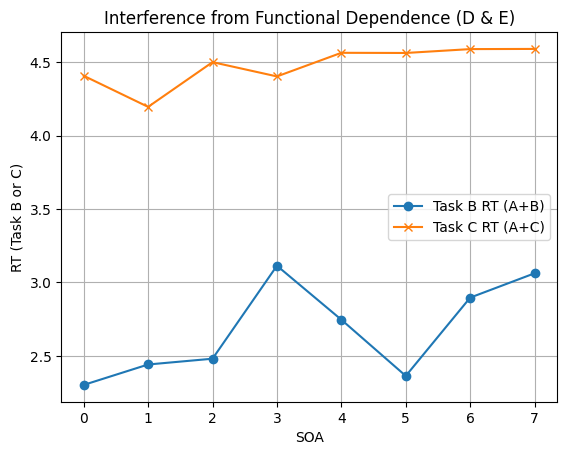

In [54]:
# Plot RTS
plt.plot(results_ab["soa"], results_ab["rt_b"], label="Task B RT (A+B)", marker='o')
plt.plot(results_ac["soa"], results_ac["rt_b"], label="Task C RT (A+C)", marker='x')
plt.xlabel("SOA")
plt.ylabel("RT (Task B or C)")
plt.title("Interference from Functional Dependence (D & E)")
plt.grid(True)
plt.legend()
plt.savefig("../output/plots/interference_functional_dependence.png", dpi=300)
plt.show()


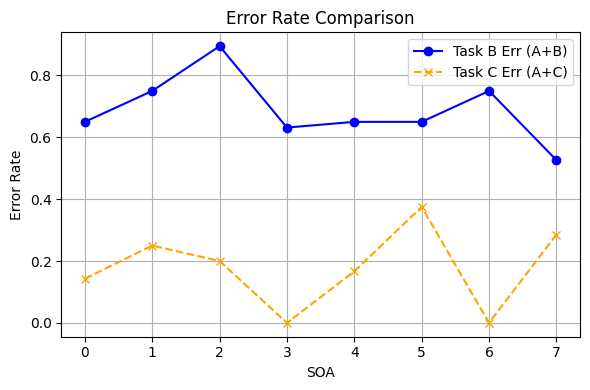

In [55]:
# Plot error rates
def plot_error_comparison(results_aX, results_aY, label_X="Task B Err (A+B)", label_Y="Task C Err (A+C)", title="Error Rate Comparison"):
    err_b_X = [1 - acc if not np.isnan(acc) else np.nan for acc in results_aX["acc_b"]]
    err_b_Y = [1 - acc if not np.isnan(acc) else np.nan for acc in results_aY["acc_b"]]

    plt.figure(figsize=(6, 4))
    plt.plot(results_aX["soa"], err_b_X, marker='o', color="blue", label=label_X)
    plt.plot(results_aY["soa"], err_b_Y, marker='x', color="orange", linestyle='--', label=label_Y)
    plt.xlabel("SOA")
    plt.ylabel("Error Rate")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

#plot
plot_error_comparison(results_ab, results_ac)


# Sim Study 3

In [11]:
from prp_model.task_generator import generate_fixed_task_set

inp, task, target, _ = generate_fixed_task_set(
    N_pathways=3,
    N_features=3,
    samples_per_task=100,
)

net = TaskNetworkWrapper(hidden_size=100)
net.train_online(inp, task, target, n_epochs=400)


Epoch 000 | Loss: 0.1067 | Accuracy: 0.37
Epoch 010 | Loss: 0.0670 | Accuracy: 0.58
Epoch 020 | Loss: 0.0498 | Accuracy: 0.79
Epoch 030 | Loss: 0.0267 | Accuracy: 0.94
Epoch 040 | Loss: 0.0203 | Accuracy: 0.95
Epoch 050 | Loss: 0.0176 | Accuracy: 0.96
Epoch 060 | Loss: 0.0161 | Accuracy: 0.97
Epoch 070 | Loss: 0.0152 | Accuracy: 0.97
Epoch 080 | Loss: 0.0144 | Accuracy: 0.97
Epoch 090 | Loss: 0.0137 | Accuracy: 0.97
Epoch 100 | Loss: 0.0130 | Accuracy: 0.97
Epoch 110 | Loss: 0.0125 | Accuracy: 0.97
Epoch 120 | Loss: 0.0119 | Accuracy: 0.97
Epoch 130 | Loss: 0.0114 | Accuracy: 0.97
Epoch 140 | Loss: 0.0110 | Accuracy: 0.97
Epoch 150 | Loss: 0.0105 | Accuracy: 0.97
Epoch 160 | Loss: 0.0101 | Accuracy: 0.97
Epoch 170 | Loss: 0.0098 | Accuracy: 0.97
Epoch 180 | Loss: 0.0094 | Accuracy: 0.97
Epoch 190 | Loss: 0.0091 | Accuracy: 0.98
Epoch 200 | Loss: 0.0089 | Accuracy: 0.98
Epoch 210 | Loss: 0.0086 | Accuracy: 0.98
Epoch 220 | Loss: 0.0084 | Accuracy: 0.98
Epoch 230 | Loss: 0.0081 | Accurac

In [3]:
def simple_trial_generator(prp_pair=("B", "A"), seed=None):
    """
    Generate a single PRP trial from the fixed task set.
    Task 1: prp_pair[0]
    Task 2: prp_pair[1]
    """
    if seed is not None:
        np.random.seed(seed)

    # Get all fixed tasks
    input_sgl, tasks_sgl, _, meta = generate_fixed_task_set(
        N_pathways=3,
        N_features=3,
        samples_per_task=1,
        seed=seed
    )

    # Map task label to task ID used in the one-hot task vectors
    label_to_index = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
    idx1 = label_to_index[prp_pair[0]]
    idx2 = label_to_index[prp_pair[1]]

    # Find matching samples
    task_ids = meta["tasks_idx"]
    ix1 = np.where(task_ids == prp_pair[0])[0][0]
    ix2 = np.where(task_ids == prp_pair[1])[0][0]

    return input_sgl[ix1], input_sgl[ix2], tasks_sgl[ix1], tasks_sgl[ix2]


# For A & B: functionally dependent
simple_trial_generator(prp_pair=("B", "A"))

# For A & C: functionally independent
simple_trial_generator(prp_pair=("C", "A"))


# B → A (functionally dependent)
results_ba = sweep_soa(
    task_net=net,
    trial_generator=lambda: simple_trial_generator(("B", "A")),
    soa_values=list(range(0, 9)),  # SOAs 0–8
    n_trials_per_soa=50,
    threshold=1.0,
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.5,
    verbose=False
)

# C → A (functionally independent)
results_ca = sweep_soa(
    task_net=net,
    trial_generator=lambda: simple_trial_generator(("C", "A")),
    soa_values=list(range(0, 9)),
    n_trials_per_soa=50,
    threshold=1.0,
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.5,
    verbose=False
)



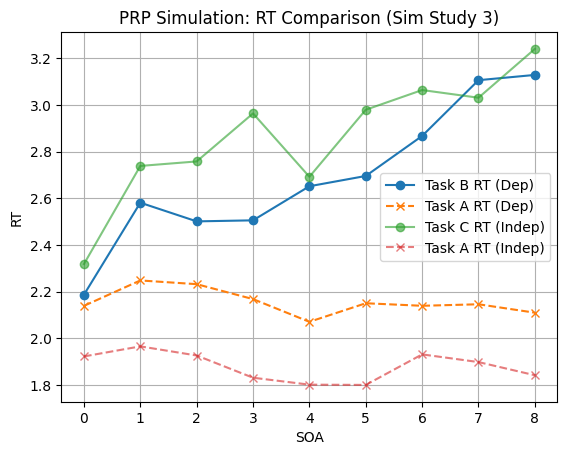

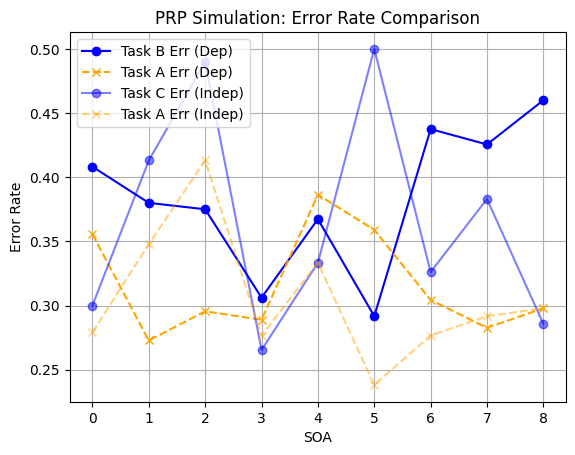

In [5]:
# Plot RTs and Error Rates

# RTs
plt.plot(results_ba["soa"], results_ba["rt_b"], label="Task B RT (Dep)", marker='o')
plt.plot(results_ba["soa"], results_ba["rt_a"], label="Task A RT (Dep)", marker='x', linestyle='--')

plt.plot(results_ca["soa"], results_ca["rt_b"], label="Task C RT (Indep)", marker='o', alpha=0.6)
plt.plot(results_ca["soa"], results_ca["rt_a"], label="Task A RT (Indep)", marker='x', linestyle='--', alpha=0.6)

plt.xlabel("SOA")
plt.ylabel("RT")
plt.title("PRP Simulation: RT Comparison (Sim Study 3)")
plt.grid(True)
plt.legend()
#plt.savefig("../output/plots/prp_simulation_rt_comparison.png", dpi=300)
plt.show()

# Error Rates
err_a_ba = [1 - a if not np.isnan(a) else np.nan for a in results_ba["acc_a"]]
err_b_ba = [1 - b if not np.isnan(b) else np.nan for b in results_ba["acc_b"]]
err_a_ca = [1 - a if not np.isnan(a) else np.nan for a in results_ca["acc_a"]]
err_c_ca = [1 - b if not np.isnan(b) else np.nan for b in results_ca["acc_b"]]

plt.plot(results_ba["soa"], err_b_ba, marker='o', label="Task B Err (Dep)", color="blue")
plt.plot(results_ba["soa"], err_a_ba, marker='x', linestyle='--', label="Task A Err (Dep)", color="orange")

plt.plot(results_ca["soa"], err_c_ca, marker='o', label="Task C Err (Indep)", color="blue", alpha=0.5)
plt.plot(results_ca["soa"], err_a_ca, marker='x', linestyle='--', label="Task A Err (Indep)", color="orange", alpha=0.5)

plt.xlabel("SOA")
plt.ylabel("Error Rate")
plt.title("PRP Simulation: Error Rate Comparison")
plt.grid(True)
plt.legend()
#plt.savefig("../output/plots/prp_simulation_error_rate_comparison.png", dpi=300)
plt.show()


### Diagnostics
**(Task similarity matrix + Cumulative RT distribution)**

In [6]:
# Task similarity matrix computation
from collections import defaultdict

def get_mean_hidden_activations(task_net, stim_inputs, task_inputs, task_ids, tau_net=1.0):
    hidden_by_task = defaultdict(list)

    for stim, task, task_id in zip(stim_inputs, task_inputs, task_ids):
        stim_t = torch.tensor(stim, dtype=torch.float32)
        task_t = torch.tensor(task, dtype=torch.float32)

        with torch.no_grad():
            x = torch.cat((stim_t, task_t))
            net_hidden = task_net.model.fc_input_to_hidden(x) + tau_net * task_net.model.task_to_hidden(task_t) - 2.0
            h = task_net.model.activation_fn(net_hidden)
            hidden_by_task[int(task_id)].append(h.detach().numpy())

    return {task_id: np.mean(hs, axis=0) for task_id, hs in hidden_by_task.items()}

def compute_task_similarity_matrix(mean_hidden):
    task_ids = sorted(mean_hidden.keys())
    activations = np.stack([mean_hidden[tid] for tid in task_ids])
    corr_matrix = np.corrcoef(activations)
    return task_ids, corr_matrix


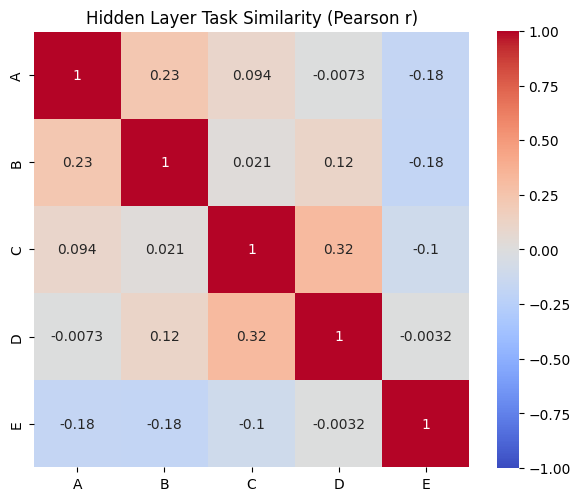

In [7]:
# If your task array is one-hot encoded: shape (N_trials, N_tasks)
# Get the index of the active task unit for each trial
task_ids_int = [int(np.argmax(t)) for t in task]

# Compute mean hidden activations per task
mean_hidden = get_mean_hidden_activations(
    task_net=net,
    stim_inputs=inp,
    task_inputs=task,
    task_ids=task_ids_int,
    tau_net=1.0  # adjust if needed
)

# Compute similarity matrix
task_ids_sorted, corr_matrix = compute_task_similarity_matrix(mean_hidden)

# Plot as Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

task_labels = ['A', 'B', 'C', 'D', 'E']  # You can adjust this if needed
df = pd.DataFrame(corr_matrix, index=task_labels, columns=task_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Hidden Layer Task Similarity (Pearson r)")
plt.tight_layout()
plt.show()



Cumulative RT Distribution

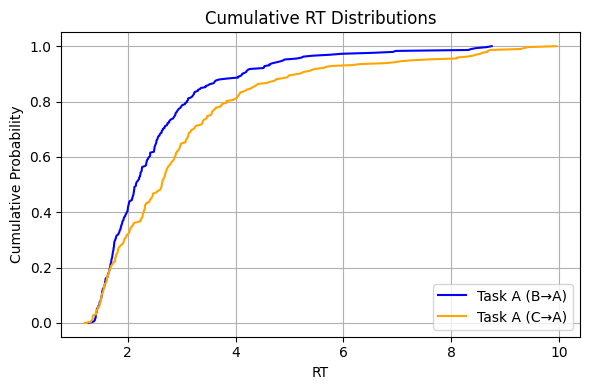

In [9]:
from prp_model.prp_simulator import run_prp_trial

def collect_prp_rts(task_net, prp_pair=("B", "A"), soa=0, n_repeats=200, **kwargs):
    rts_task1 = []
    rts_task2 = []

    for _ in range(n_repeats):
        s1, s2, t1, t2 = simple_trial_generator(prp_pair)
        rt1, _, rt2, _, _ = run_prp_trial(
            task_net, s1, s2, t1, t2, soa=soa, **kwargs
        )
        if rt1 is not None and rt2 is not None:
            rts_task1.append(rt1)
            rts_task2.append(rt2)

    return np.array(rts_task1), np.array(rts_task2)



def plot_cumulative_rt(rt1, rt2, label1="Task 1", label2="Task 2", color1="blue", color2="orange"):
    plt.figure(figsize=(6, 4))
    sorted1 = np.sort(rt1)
    sorted2 = np.sort(rt2)
    cum1 = np.linspace(0, 1, len(sorted1))
    cum2 = np.linspace(0, 1, len(sorted2))

    plt.plot(sorted1, cum1, label=label1, color=color1)
    plt.plot(sorted2, cum2, label=label2, color=color2)

    plt.xlabel("RT")
    plt.ylabel("Cumulative Probability")
    plt.title("Cumulative RT Distributions")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    #plt.savefig("../output/plots/cumulative_rt_comparison.png", dpi=300)
    plt.show()



rts_b, rts_a_b = collect_prp_rts(net, prp_pair=("B", "A"), soa=2, n_repeats=300)
rts_c, rts_a_c = collect_prp_rts(net, prp_pair=("C", "A"), soa=2, n_repeats=300)

# Plot cumulative RT for Task A in both cases
plot_cumulative_rt(rts_a_b, rts_a_c, label1="Task A (B→A)", label2="Task A (C→A)")
